<a href="https://colab.research.google.com/github/jlvi179/Advanced-Deep-Learning/blob/main/Submission2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncertainty Prediction for Astronomical Data
## Neural Network with Gaussian NLL Loss

Predict temperature, gravity, metallicity with their uncertainties.

In [1]:
import os
import copy
import sys
import numpy as np
import torch
import torch.nn as nn
import math
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from huggingface_hub import hf_hub_download
import torch.optim as optim
import time

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, current_dir)
sys.path.insert(0, parent_dir)


def normalize(labels, p):
    """
    Normalize the input labels using percentile-based scaling.

    This function scales the input labels to a range of [0, 1] based on the specified percentiles.
    The scaling is done by computing the percentiles of the labels and then normalizing the labels
    using these percentile values.

    Parameters:
    labels (np.ndarray): The input labels to be normalized.
    p (float): The percentile value used for scaling. The function uses the p-th and (1-p)-th percentiles
               for normalization.

    Returns:
    tuple: A tuple containing the normalized labels and the range used for normalization.
           - normalized_labels (np.ndarray): The normalized labels.
           - ranges (np.ndarray): The range used for normalization, which includes the p-th and (1-p)-th percentiles.
    """
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):
    """
    Denormalize the input labels using the specified range.

    This function denormalizes the input labels using the specified range values.
    The denormalization is done by scaling the labels back to the original range
    using the provided range values.

    Parameters:
        labels (np.ndarray): The normalized labels to be  denormalized.
        ranges (np.ndarray): The range values used for normalization.

    Returns:
        np.ndarray: The denormalized labels.
    """
    return labels * (ranges[1] - ranges[0]) + ranges[0]

def denormalize_std(uncertainty, ranges):
    """
    Denormalizes the given uncertainty predictions using the provided range.

    It is different to the denormalization of the labels which also includes a shift.

    Parameters
    ----------
    uncertainty : array-like
        The normalized uncertainty to be denormalized.
    ranges : array-like
        A two-element array-like object where the first element is the minimum value
        and the second element is the maximum value of the original range.
    Returns
    -------
    array-like
        The denormalized uncertainty.
    """

    return uncertainty * (ranges[1] - ranges[0])


def get_normalized_data(data_path, return_SNR=False):
    """
    Load and normalize spectra and label data from the given path.
    Parameters
    ----------
    data_path : str
        The path to the directory containing the spectra and labels data files.
    Returns
    -------
    spectra : numpy.ndarray
        The normalized spectra data.
    labels : numpy.ndarray
        The normalized labels data (t_eff, log_g, fe_h).
    spectra_length : int
        The length of the spectra.
    n_labels : int
        The number of labels used (should be 3).
    labelNames : list of str
        The names of the labels used (t_eff, log_g, fe_h).
    ranges : numpy.ndarray
        The ranges used for normalization of the labels.
    """

    # Load the spectra data
    spectra = np.load(f"{data_path}/spectra.npy")
    spectra_length = spectra.shape[1]

    # Load the labels data
    # labels: mass, age, l_bol, dist, t_eff, log_g, fe_h
    labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h"]
    labels = np.load(f"{data_path}/labels.npy")
    SNR = labels[:, -1]
    labels = labels[:, :-1]

    # We only use the labels: t_eff, log_g, fe_h
    labelNames = labelNames[-3:]
    labels = labels[:, -3:]
    n_labels = labels.shape[1]

    labels, ranges = normalize(labels, 0.05)

    # Normalize spectra
    spectra = np.log(np.maximum(spectra, 0.2))

    if return_SNR:
        return spectra, labels, spectra_length, n_labels, labelNames, ranges, SNR
    return spectra, labels, spectra_length, n_labels, labelNames, ranges


def train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):
    """
    Trains a given model using the provided training and validation data loaders, loss function, and optimizer.

        Parameters
        ----------
        model : torch.nn.Module
            The neural network model to be trained.
        train_loader : torch.utils.data.DataLoader
            DataLoader for the training dataset.
        val_loader : torch.utils.data.DataLoader
            DataLoader for the validation dataset.
        loss_function : torch.nn.Module
            Loss function to be used for training.
        learning_rate : float
            learning rate
        num_epochs : int
            Number of epochs to train the model.
        patience : int
            Number of epochs with no improvement after which training will be stopped.
        device : torch.device
            Device on which to perform training (e.g., 'cpu' or 'cuda').
        plot_fn : callable, optional
            Function to plot the model predictions during training. Default is None.
        plot_interval : int, optional
            Interval at which to plot the model predictions during training. Default is 10.
        plot_kwargs : dict, optional
            Additional keyword arguments to be passed to the plot function. Default is None.
        model_name : str, optional
            Name of the model for saving the best model. Default is None.
            If provided, the best model will be saved to the "models" directory with the given name.

        Returns
        -------
        tuple
            A tuple containing two lists:
            - train_losses (list of float): List of average training losses for each epoch.
            - val_losses (list of float): List of average validation losses for each epoch.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()  # Start the timer for this epoch

        # Training phase
        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)  # Add channel dimension for CNNs
            optimizer.zero_grad()

            loss=loss_function(batch_spectra, batch_labels, model)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Print progress every 10th step, updating the same line
            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")  # Move to the next line after the epoch

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

                val_loss=loss_function(batch_spectra, batch_labels, model)

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Print epoch summary
        epoch_time = time.time() - start_time  # Calculate epoch time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if(epoch%plot_interval==0):
            if(plot_fn is not None):

                assert(plot_kwargs is not None)

                assert("test_loader" in plot_kwargs.keys())
                assert("ranges" in plot_kwargs.keys())
                assert("plot_folder" in plot_kwargs.keys())

                plot_fn(model,
                        plot_kwargs["test_loader"],
                        loss_function,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)

    return train_losses, val_losses, best_model

def evaluate_model(model, test_loader, loss_function, device):
    """
    Evaluate the given model on the test dataset.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to evaluate.
    test_loader : torch.utils.data.DataLoader
        DataLoader for the test dataset.
    loss_function : callable
        Loss function used to compute the loss.
    device : torch.device
        Device on which to perform computations (e.g., 'cpu' or 'cuda').

    Returns
    -------
    all_predictions : numpy.ndarray
        Array of denormalized predictions made by the model.
    all_true_labels : numpy.ndarray
        Array of denormalized true labels from the test dataset.
    """
    print("Evaluating model on the test dataset...")
    model.eval()
    total_test_loss = 0.0
    all_predictions = []
    all_true_labels = []

    first_batch_spectra=None
    first_batch_labels=None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            predictions = model(batch_spectra)

            test_loss = loss_function(batch_spectra, batch_labels,model)

            total_test_loss += test_loss.item()
            all_predictions.append(predictions.cpu())
            all_true_labels.append(batch_labels.cpu())

            if(batch_index==0):
                first_batch_spectra=batch_spectra
                first_batch_labels=batch_labels



    avg_test_loss = total_test_loss / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels





Sorry, this code box contains the helper.py file. I dont really like the structure and file explorer of colab, but I still need it to compute my code. On my machine it takes like forever.

## Model Architecture

In [2]:
class TinyCNNWithUncertainty(nn.Module):
    def __init__(self, n_labels):
        super(TinyCNNWithUncertainty, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 10, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),

            nn.Conv1d(10, 20, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(20),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),

            nn.Conv1d(20, 40, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(40),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),

            nn.Conv1d(40, 10, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(2),

            nn.Conv1d(10, 12, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(12),
            nn.Dropout(0.2),

            nn.Conv1d(12, 10, kernel_size=1),
            nn.Dropout(0.2),
        )

        self.fc_shared = nn.Sequential(
            nn.Linear(300, 32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(10 * 32, 128),
            nn.ReLU(),
        )

        self.fc_mean = nn.Linear(128, n_labels)
        self.fc_logstd = nn.Linear(128, n_labels)
        self.n_labels = n_labels

    def forward(self, x):
        x = self.features(x)
        x = self.fc_shared(x)
        mean = self.fc_mean(x)
        logstd = self.fc_logstd(x)
        return torch.cat([mean, logstd], dim=1)

    def get_predictions_and_uncertainties(self, x):
        output = self.forward(x)
        mean = output[:, :self.n_labels]
        logstd = output[:, self.n_labels:]
        std = torch.exp(logstd)
        return mean, std

## Loss Function - Gaussian NLL

In [3]:
def nll_loss(predictions, batch_labels, n_labels):
    """Negative log-likelihood loss: 0.5*((y-mu)/sigma)^2 + log(sigma)"""
    mean = predictions[:, :n_labels]
    log_std = predictions[:, n_labels:]
    std = torch.exp(log_std)
    return torch.mean(0.5 * ((batch_labels - mean) / std) ** 2 + log_std)

## Load Data

In [4]:
DATA_PATH = os.path.abspath(os.path.join(parent_dir, "data", "4"))
learning_rate = 2e-4
batch_size = 32
num_epochs = 100
patience = 10

def ensure_data_downloaded(data_path):
    os.makedirs(data_path, exist_ok=True)
    for filename in ("labels.npy", "spectra.npy"):
        target_file = os.path.join(data_path, filename)
        if os.path.exists(target_file):
            continue
        print(f"Downloading {filename}...")
        hf_hub_download(
            repo_id="simbaswe/galah4",
            filename=filename,
            repo_type="dataset",
            local_dir=data_path,
        )

ensure_data_downloaded(DATA_PATH)
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)
print(f"Data loaded: {spectra.shape[0]} samples, Labels: {labelNames}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


labels.npy:   0%|          | 0.00/285k [00:00<?, ?B/s]

spectra.npy:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Data loaded: 8914 samples, Labels: ['t_eff', 'log_g', 'fe_h']


## Create Data Loaders

In [5]:
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

total_samples = len(spectra_tensor)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(spectra_tensor, labels_tensor),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Train Model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyCNNWithUncertainty(n_labels).to(device)
loss_function = lambda batch_spectra, batch_labels, model_ref: nll_loss(model_ref(batch_spectra), batch_labels, n_labels)

train_losses, val_losses, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    model_name=None,
)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch [1/100], Step [190/195], Loss: -1.2589
Epoch [1/100], Train Loss: -0.9363, Val Loss: -1.4091, Time: 4.06 seconds
Epoch [2/100], Step [190/195], Loss: -1.5567
Epoch [2/100], Train Loss: -1.3965, Val Loss: -1.5686, Time: 2.21 seconds
Epoch [3/100], Step [190/195], Loss: -1.5286
Epoch [3/100], Train Loss: -1.5435, Val Loss: -1.7651, Time: 2.69 seconds
Epoch [4/100], Step [190/195], Loss: -1.6940
Epoch [4/100], Train Loss: -1.6912, Val Loss: -1.9148, Time: 2.36 seconds
Epoch [5/100], Step [190/195], Loss: -1.6703
Epoch [5/100], Train Loss: -1.7575, Val Loss: -1.8323, Time: 2.22 seconds
Epoch [6/100], Step [190/195], Loss: -1.7400
Epoch [6/100], Train Loss: -1.7985, Val Loss: -1.9695, Time: 2.20 seconds
Epoch [7/100], Step [190/195], Loss: -1.7478
Epoch [7/100], Train Loss: -1.8373, Val Loss: -1.8746, Time: 2.18 seconds
Epoch [8/100], Step [190/195], Loss: -1.8497
Epoch [8/100], Train Loss: -1.8801, Val Loss: -2.0739, Time: 2.19 seconds
Epoch [9/100], Step [190/195], Loss: -1.8721
Epo

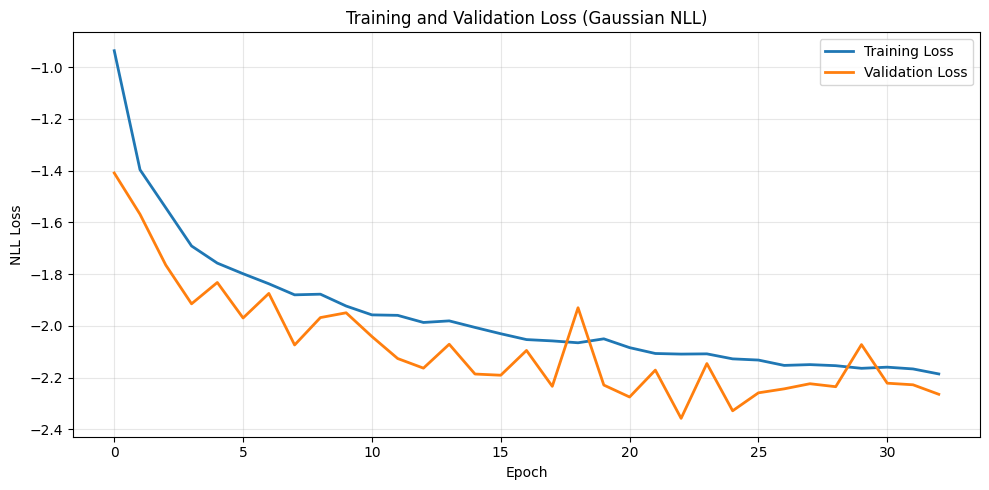

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("NLL Loss")
plt.title("Training and Validation Loss (Gaussian NLL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Training Loss History

## Evaluate on Test Set

In [8]:
model.eval()
predictions, uncertainties, truths = [], [], []

with torch.no_grad():
    for batch_spectra, batch_labels in test_loader:
        batch_spectra = batch_spectra.to(device).unsqueeze(1)
        means, stds = model.get_predictions_and_uncertainties(batch_spectra)
        predictions.append(means.cpu().numpy())
        uncertainties.append(stds.cpu().numpy())
        truths.append(batch_labels.numpy())

predictions = np.vstack(predictions)
uncertainties = np.vstack(uncertainties)
true_labels = np.vstack(truths)

predictions_denorm = denormalize(predictions, ranges)
true_labels_denorm = denormalize(true_labels, ranges)
uncertainties_denorm = np.column_stack(
    [denormalize_std(uncertainties[:, i], ranges[:, i]) for i in range(n_labels)]
)

residuals = predictions_denorm - true_labels_denorm
standardized_residuals = residuals / uncertainties_denorm

## Quantify Uncertainty Quality: Pull Distribution

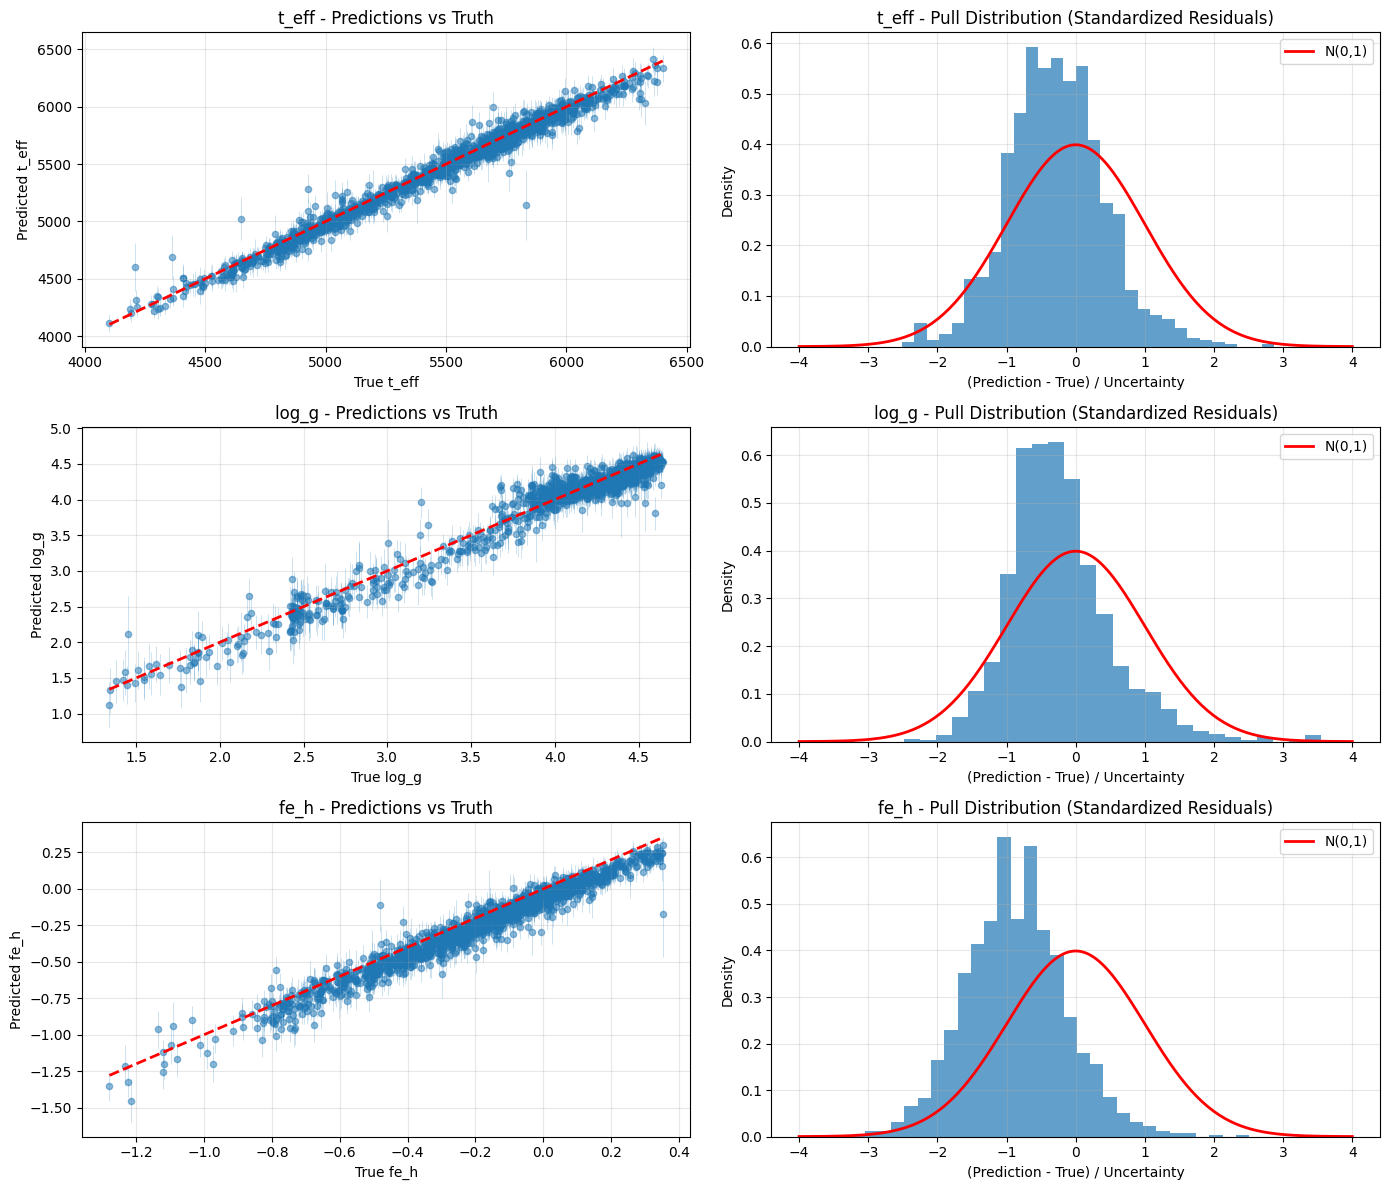

Pull Distribution Analysis (should match N(0,1)):
  t_eff     : mean=-0.2791, std= 0.7067
  log_g     : mean=-0.2307, std= 0.7478
  fe_h      : mean=-0.8656, std= 0.7294


In [9]:
x = np.linspace(-4, 4, 200)
normal_pdf = np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(n_labels, 2, figsize=(14, 4 * n_labels))
if n_labels == 1:
    axes = axes.reshape(1, -1)

for i, label_name in enumerate(labelNames):
    idx = np.argsort(true_labels_denorm[:, i])

    ax = axes[i, 0]
    ax.scatter(true_labels_denorm[idx, i], predictions_denorm[idx, i], alpha=0.5, s=20)
    ax.errorbar(true_labels_denorm[idx, i], predictions_denorm[idx, i],
                yerr=uncertainties_denorm[idx, i], fmt="none", elinewidth=0.5, alpha=0.3)
    ax.plot([true_labels_denorm[:, i].min(), true_labels_denorm[:, i].max()],
            [true_labels_denorm[:, i].min(), true_labels_denorm[:, i].max()],
            "r--", linewidth=2)
    ax.set_title(f"{label_name} - Predictions vs Truth")
    ax.set_xlabel("True " + label_name)
    ax.set_ylabel("Predicted " + label_name)
    ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    ax.hist(standardized_residuals[:, i], bins=30, alpha=0.7, density=True)
    ax.plot(x, normal_pdf, "r-", linewidth=2, label="N(0,1)")
    ax.set_title(f"{label_name} - Pull Distribution (Standardized Residuals)")
    ax.set_xlabel("(Prediction - True) / Uncertainty")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("Pull Distribution Analysis (should match N(0,1)):")
for i, label_name in enumerate(labelNames):
    pull_mean = np.mean(standardized_residuals[:, i])
    pull_std = np.std(standardized_residuals[:, i])
    print(f"  {label_name:10s}: mean={pull_mean:7.4f}, std={pull_std:7.4f}")

## Calibration Plot - Check Uncertainty Correctness

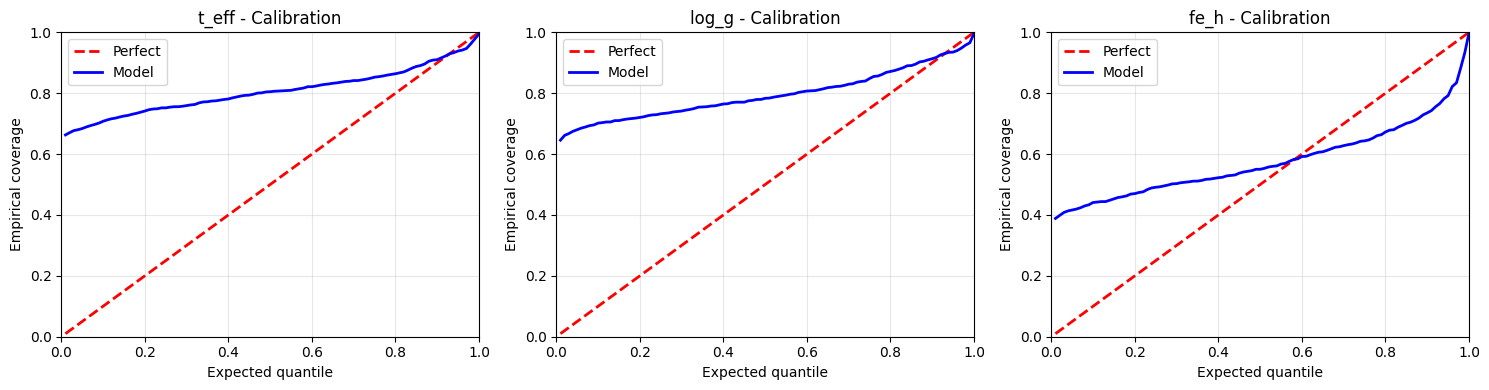


Well-calibrated model: Blue line should follow red diagonal.
This shows predicted uncertainties match actual prediction errors.


In [10]:
fig, axes = plt.subplots(1, n_labels, figsize=(5 * n_labels, 4))
if n_labels == 1:
    axes = [axes]

percentiles = np.arange(1, 101) / 100
for i, label_name in enumerate(labelNames):
    abs_residuals = np.abs(residuals[:, i])
    empirical = [np.mean(abs_residuals <= np.percentile(uncertainties_denorm[:, i], p * 100)) for p in percentiles]
    axes[i].plot(percentiles, percentiles, "r--", linewidth=2, label="Perfect")
    axes[i].plot(percentiles, empirical, "b-", linewidth=2, label="Model")
    axes[i].set_title(f"{label_name} - Calibration")
    axes[i].set_xlabel("Expected quantile")
    axes[i].set_ylabel("Empirical coverage")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

print("\nWell-calibrated model: Blue line should follow red diagonal.")
print("This shows predicted uncertainties match actual prediction errors.")